In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("bengaluru_house_prices.csv")

In [3]:
df.shape

(13320, 9)

In [4]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [6]:
df['total_sqft'].unique()

<ArrowStringArray>
[       '1056',        '2600',        '1440',        '1521',        '1200',
        '1170',        '2732',        '3300',        '1310',        '1020',
 ...
        '3124',        '9200',         '613',         '250',        '2395',
 '1020 - 1130',        '2758', '1133 - 1384',         '774',        '4689']
Length: 2117, dtype: str

In [7]:
L=[]
for i in df['total_sqft']:
    s=i.split(" - ")
    if s[0].isdigit() :
        L.append(int(s[0]))
    else:
        L.append(np.nan)

In [8]:
df['total_sqft1']=L

In [9]:
df[['total_sqft','total_sqft1']]

,total_sqft,total_sqft1
0,1056,1056.0
1,2600,2600.0
2,1440,1440.0
3,1521,1521.0
4,1200,1200.0
...,...,...
13315,3453,3453.0
13316,3600,3600.0
13317,1141,1141.0
13318,4689,4689.0


In [10]:
df[['total_sqft','total_sqft1']].info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   total_sqft   13320 non-null  str    
 1   total_sqft1  13182 non-null  float64
dtypes: float64(1), str(1)
memory usage: 260.4 KB


In [11]:
df.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
total_sqft1      138
dtype: int64

In [12]:
df.isna().mean()*100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
total_sqft1      1.036036
dtype: float64

In [13]:
df.drop(columns="society",inplace=True)
df.dropna(inplace=True)

In [14]:
df.drop(columns=["availability","total_sqft"],inplace=True)

In [15]:
df.rename(columns={'total_sqft1': 'total_sqft'}, inplace=True)

In [16]:
df.isna().sum()

area_type     0
location      0
size          0
bath          0
balcony       0
price         0
total_sqft    0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(684)

In [18]:
df.describe()

,bath,balcony,price,total_sqft
count,12579.000000,12579.000000,12579.000000,12579.000000
mean,2.613880,1.586295,105.709331,1509.243104
std,1.225025,0.817165,131.873587,1164.083210
min,1.000000,0.000000,8.000000,5.000000
25%,2.000000,1.000000,49.000000,1100.000000
50%,2.000000,2.000000,70.000000,1258.000000
75%,3.000000,2.000000,114.500000,1636.000000
max,40.000000,3.000000,2912.000000,52272.000000


In [19]:
df.describe(include="O")

,area_type,location,size
count,12579,12579,12579
unique,4,1257,27
top,Super built-up Area,Whitefield,2 BHK
freq,8405,513,5124


In [20]:
df.info()

<class 'pandas.DataFrame'>
Index: 12579 entries, 0 to 13319
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   12579 non-null  str    
 1   location    12579 non-null  str    
 2   size        12579 non-null  str    
 3   bath        12579 non-null  float64
 4   balcony     12579 non-null  float64
 5   price       12579 non-null  float64
 6   total_sqft  12579 non-null  float64
dtypes: float64(4), str(3)
memory usage: 1.2 MB


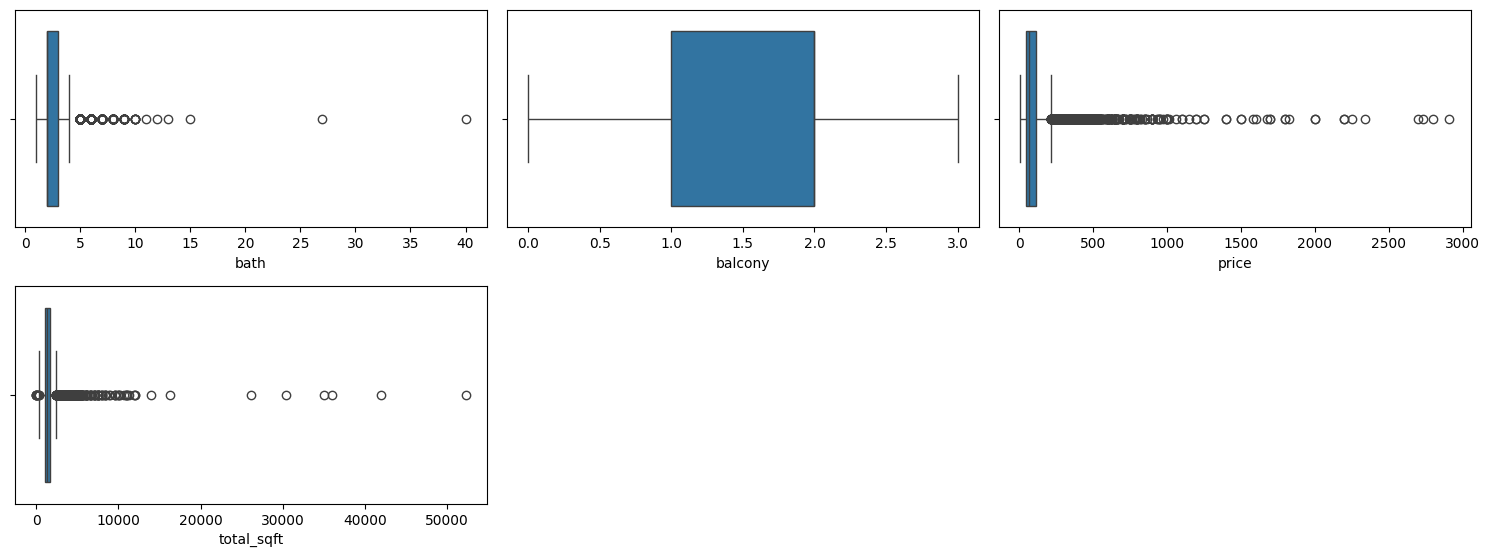

In [21]:
plt.figure(figsize=(15,8))
c=1
for i in df.describe().columns:
    plt.subplot(3,3,c)
    sns.boxplot(x=df[i])
    plt.tight_layout()
    c+=1

In [22]:
df

,area_type,location,size,bath,balcony,price,total_sqft
0,Super built-up Area,Electronic City Phase II,2 BHK,2.0,1.0,39.07,1056.0
1,Plot Area,Chikka Tirupathi,4 Bedroom,5.0,3.0,120.00,2600.0
2,Built-up Area,Uttarahalli,3 BHK,2.0,3.0,62.00,1440.0
3,Super built-up Area,Lingadheeranahalli,3 BHK,3.0,1.0,95.00,1521.0
4,Super built-up Area,Kothanur,2 BHK,2.0,1.0,51.00,1200.0
...,...,...,...,...,...,...,...
13314,Super built-up Area,Green Glen Layout,3 BHK,3.0,3.0,112.00,1715.0
13315,Built-up Area,Whitefield,5 Bedroom,4.0,0.0,231.00,3453.0
13317,Built-up Area,Raja Rajeshwari Nagar,2 BHK,2.0,1.0,60.00,1141.0
13318,Super built-up Area,Padmanabhanagar,4 BHK,4.0,1.0,488.00,4689.0


In [27]:
df.isna().sum()

area_type     0
location      0
size          0
bath          0
balcony       0
price         0
total_sqft    0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(684)

In [29]:
df.drop_duplicates(inplace=True)

In [31]:
df = df.reset_index(drop=True)

In [32]:
df

,area_type,location,size,bath,balcony,price,total_sqft
0,Super built-up Area,Electronic City Phase II,2 BHK,2.0,1.0,39.07,1056.0
1,Plot Area,Chikka Tirupathi,4 Bedroom,5.0,3.0,120.00,2600.0
2,Built-up Area,Uttarahalli,3 BHK,2.0,3.0,62.00,1440.0
3,Super built-up Area,Lingadheeranahalli,3 BHK,3.0,1.0,95.00,1521.0
4,Super built-up Area,Kothanur,2 BHK,2.0,1.0,51.00,1200.0
...,...,...,...,...,...,...,...
11890,Super built-up Area,Bellandur,2 BHK,2.0,2.0,47.00,1262.0
11891,Super built-up Area,Green Glen Layout,3 BHK,3.0,3.0,112.00,1715.0
11892,Built-up Area,Whitefield,5 Bedroom,4.0,0.0,231.00,3453.0
11893,Built-up Area,Raja Rajeshwari Nagar,2 BHK,2.0,1.0,60.00,1141.0


In [47]:
X = df.drop("price", axis=1)
y = df["price"]

In [48]:
X = pd.get_dummies(X, drop_first=True)

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [53]:
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.5755619503963254
MAE: 38.58378386479844
MSE: 8603.057136218395


In [55]:
result = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})
print(result.head(10))

      Actual Price  Predicted Price
2620         70.20        94.257137
7864         65.00        85.405276
9833         59.00        52.793320
9355        145.00       121.815714
1208         38.34        26.229471
8839         55.00        44.244551
6556        252.00       305.037877
7498        341.00       280.530612
9185         85.00        97.806911
3465         38.00        47.382982
